## 1. Исходная модель

Необходимо найти приближенное решение **смешанной краевой задачи** для неоднородного уравнения теплопроводности в области с разрывными теплофизическими свойствами (композитный стержень).

Рассматривается одномерная область, состоящая из двух слоев:
*   **Слой 1:** $x \in [0, a]$ с коэффициентом температуропроводности $k_1$.
*   **Слой 2:** $x \in [a, L]$ с коэффициентом температуропроводности $k_2$.

Общее уравнение теплопроводности имеет вид:
$$ u_t = \frac{\partial}{\partial x} \left( \chi(x) \frac{\partial u}{\partial x} \right) + f(x, t) $$
Однако в данной постановке задача сводится к системе двух уравнений с разными коэффициентами и отсутствием источника ($f(x,t)=0$, если не указано иное, или источник учитывается позже).

## 2. Математическая формулировка задачи

Система уравнений в частных производных с соответствующими начальными и граничными условиями формулируется следующим образом:

$$
\begin{cases}
\begin{aligned}
&\frac{\partial u_1}{\partial t} = k_1 \frac{\partial^2 u_1}{\partial x^2}, \quad 0 < x < a, \quad t > 0, \\[4pt]
&\frac{\partial u_2}{\partial t} = k_2 \frac{\partial^2 u_2}{\partial x^2}, \quad a < x < L, \quad t > 0,
\end{aligned}
\end{cases}
$$

### Начальное условие
Задача рассматривается при нулевом начальном распределении температуры:
$$ u_1(x, 0) = u_2(x, 0) = 0, \quad x \in [0, L] $$

### Граничные условия
На левом конце стержня задан постоянный тепловой поток (условие второго рода — Неймана), на правом конце — условие теплоизоляции (производная равна нулю):
$$
\begin{cases}
-\chi_1 \frac{\partial u_1}{\partial x}(0, t) = q, \quad t > 0, \\[4pt]
\frac{\partial u_2}{\partial x}(L, t) = 0, \quad t > 0.
\end{cases}
$$

### Условия сопряжения (на границе раздела сред $x = a$)
На внутренней границе контакта двух материалов выполняются условия идеального теплового контакта:
1.  **Равенство температур** (условие непрерывности поля температуры):
    $$ u_1(a, t) = u_2(a, t), \quad t > 0 $$
2.  **Равенство тепловых потоков** (условие непрерывности потока тепла с учетом разных коэффициентов теплопроводности $\chi_1$ и $\chi_2$):
    $$ \chi_1 \frac{\partial u_1}{\partial x}(a, t) = \chi_2 \frac{\partial u_2}{\partial x}(a, t), \quad t > 0 $$

## Итоговая постановка задачи:

$$
\begin{cases}
\dfrac{\partial u_1}{\partial t} = k_1 \dfrac{\partial^2 u_1}{\partial x^2}, \quad 0 < x < a, \quad t \in (0, T], \\
\dfrac{\partial u_2}{\partial t} = k_2 \dfrac{\partial^2 u_2}{\partial x^2}, \quad a < x < L, \quad t \in (0, T], \\
u_1(x, 0) = u_2(x, 0) = 0, \\
-\chi_1 \dfrac{\partial u_1}{\partial x}(0, t) = q, \\
\dfrac{\partial u_2}{\partial x}(L, t) = 0, \\
u_1(a, t) = u_2(a, t), \\
\chi_1 \dfrac{\partial u_1}{\partial x}(a, t) = \chi_2 \dfrac{\partial u_2}{\partial x}(a, t).
\end{cases}
$$

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d

In [14]:
def solve_heat_cn_composite(x_min, x_max, t_max, Nx, Nt, a_interface, k1, k2, q_flux, save_history=True):
    h = (x_max - x_min) / Nx
    tau = t_max / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    t = np.linspace(0, t_max, Nt + 1)
    
    chi = np.where(x < a_interface, k1, k2)
    
    # Начальное условие: u(x, 0) = 0
    u = np.zeros(Nx + 1)
    u_new = np.zeros(Nx + 1)
    
    # Параметр схемы
    r = tau / (h * h)
    
    # Массивы для прогонки
    a = np.zeros(Nx + 1)
    b = np.zeros(Nx + 1)
    c = np.zeros(Nx + 1)
    d = np.zeros(Nx + 1)
    
    # Находим индекс границы раздела
    interface_idx = np.argmin(np.abs(x - a_interface))
    
    if save_history:
        U_history = [u.copy()]
    else:
        U_history = None
    
    # Временной цикл
    for n in range(Nt):
        # Заполнение матрицы для метода прогонки
        for i in range(1, Nx):
            if i == interface_idx:
                # Специальная обработка узла на границе раздела
                # Используем условия сопряжения
                chi_left = chi[i-1]
                chi_right = chi[i+1]
                
                # Коэффициенты для схемы с учетом разрыва коэффициентов
                a[i] = -0.5 * r * chi_left
                b[i] = 1.0 + 0.5 * r * (chi_left + chi_right)
                c[i] = -0.5 * r * chi_right
            else:
                # Обычные внутренние узлы
                chi_center = chi[i]
                a[i] = -0.5 * r * chi_center
                b[i] = 1.0 + r * chi_center
                c[i] = -0.5 * r * chi_center
        
        # Левая граница (Нейман: -χ·∂u/∂x = q)
        # Аппроксимация второго порядка
        b[0] = 1.0 + r * chi[0]
        c[0] = -r * chi[0]
        
        # Правая граница (Нейман: ∂u/∂x = 0)
        a[Nx] = -r * chi[Nx]
        b[Nx] = 1.0 + r * chi[Nx]
        
        # Формирование правой части
        for i in range(1, Nx):
            if i == interface_idx:
                # Правая часть для границы раздела
                chi_left = chi[i-1]
                chi_right = chi[i+1]
                d[i] = (0.5 * r * chi_left) * u[i-1] + \
                       (1.0 - 0.5 * r * (chi_left + chi_right)) * u[i] + \
                       (0.5 * r * chi_right) * u[i+1]
            else:
                chi_center = chi[i]
                d[i] = (0.5 * r * chi_center) * u[i-1] + \
                       (1.0 - r * chi_center) * u[i] + \
                       (0.5 * r * chi_center) * u[i+1]
        
        # Левая граница: условие с тепловым потоком
        d[0] = u[0] + r * chi[0] * (u[1] - u[0]) + 2.0 * tau * q_flux / h
        
        # Правая граница: теплоизоляция
        d[Nx] = u[Nx] + r * chi[Nx] * (u[Nx-1] - u[Nx])
        
        # Решение СЛАУ методом прогонки
        # Прямой ход
        for i in range(1, Nx + 1):
            m = a[i] / b[i-1]
            b[i] = b[i] - m * c[i-1]
            d[i] = d[i] - m * d[i-1]
        
        # Обратный ход
        u_new[Nx] = d[Nx] / b[Nx]
        for i in range(Nx - 1, -1, -1):
            u_new[i] = (d[i] - c[i] * u_new[i+1]) / b[i]
        
        u[:] = u_new[:]
        
        if save_history:
            U_history.append(u.copy())
    
    if save_history:
        return x, t, np.array(U_history)
    else:
        return x, u, t_max

In [15]:
def plot_temperature_evolution(x, t, U, a_interface, k1, k2, q_flux_value):
    from matplotlib.gridspec import GridSpec
    
    fig = plt.figure(figsize=(15, 12))
    gs = GridSpec(2, 2, figure=fig)
    
    # 3D поверхность (занимает всю левую колонку)
    ax1 = fig.add_subplot(gs[:, 0], projection='3d')
    X, T = np.meshgrid(x, t)
    surf = ax1.plot_surface(X, T, U, cmap='viridis', alpha=0.9, edgecolor='none')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('t', fontsize=12)
    ax1.set_zlabel('u(x,t)', fontsize=12)
    ax1.set_title('Распределение температуры u(x,t)', fontsize=14, fontweight='bold')
    plt.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
    interface_idx = np.argmin(np.abs(x - a_interface))
    y_line = np.linspace(0, t[-1], 10)
    z_line = U[:, interface_idx][::len(t)//9]
    ax1.plot([a_interface]*10, y_line, z_line, 'r--', linewidth=2, alpha=0.7)
    
    # Профили температуры (справа сверху)
    ax2 = fig.add_subplot(gs[0, 1])
    Nt, Nx = U.shape
    t_indices = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]
    colors = plt.cm.viridis(np.linspace(0, 1, len(t_indices)))
    for i, idx in enumerate(t_indices):
        ax2.plot(x, U[idx, :], '-', color=colors[i], linewidth=2, 
                label=f't = {t[idx]:.3f}')
    ax2.axvline(x=a_interface, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('u(x,t)', fontsize=12)
    ax2.set_title('Профили температуры', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Температура в точках (справа снизу)
    ax3 = fig.add_subplot(gs[1, 1])
    x_indices = [0, Nx//4, Nx//2, 3*Nx//4, Nx-1]
    colors = plt.cm.plasma(np.linspace(0, 1, len(x_indices)))
    for i, idx in enumerate(x_indices):
        ax3.plot(t, U[:, idx], '-', color=colors[i], linewidth=2, 
                label=f'x = {x[idx]:.3f}')
    ax3.axvline(x=a_interface, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax3.set_xlabel('t', fontsize=12)
    ax3.set_ylabel('u(x,t)', fontsize=12)
    ax3.set_title('Температура в точках', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('images1/composite_rod_solution.png', dpi=150, bbox_inches='tight')
    plt.show()

In [21]:
def check_interface_conditions(x, t, U, a_interface, k1, k2):
    # Проверяем размерность U
    if U.shape[0] == len(t):  # U имеет размерность (Nt+1, Nx+1)
        Nt = U.shape[0] - 1  # Количество временных интервалов
        U_for_flux = U[:-1, :]  # Используем все слои кроме последнего для потока
    else:  # U имеет размерность (Nt, Nx+1)
        Nt = U.shape[0]
        U_for_flux = U
    
    Nx = U.shape[1] - 1
    h = x[1] - x[0]
    
    # print(f"Размерности: U.shape = {U.shape}, t.shape = {t.shape}")
    print(f"Nt = {Nt}, Nx = {Nx}")
    
    # Находим индекс узла, ближайшего к границе раздела
    interface_idx = np.argmin(np.abs(x - a_interface))
    
    # Проверка непрерывности температуры
    temp_jump = np.abs(U[:, interface_idx] - U[:, interface_idx])
    
    # Проверка непрерывности теплового потока
    flux_left = np.zeros(Nt)
    flux_right = np.zeros(Nt)
    
    for n in range(Nt):
        # Левосторонняя производная
        if interface_idx > 0:
            du_dx_left = (U_for_flux[n, interface_idx] - U_for_flux[n, interface_idx-1]) / h
            flux_left[n] = -k1 * du_dx_left
        
        # Правосторонняя производная
        if interface_idx < Nx:
            du_dx_right = (U_for_flux[n, interface_idx+1] - U_for_flux[n, interface_idx]) / h
            flux_right[n] = -k2 * du_dx_right
    
    flux_jump = np.abs(flux_left - flux_right)
    
    # print(f"Размерности после вычислений: flux_left.shape = {flux_left.shape}")
    
    # Визуализация проверки условий
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Для потока используем t без последнего элемента
    t_flux = t[:Nt]  # Берем первые Nt элементов
    
    # print(f"Для построения: t_flux.shape = {t_flux.shape}, flux_left.shape = {flux_left.shape}")
    
    axes[0].plot(t_flux, flux_left, 'b-', linewidth=2, label='Поток слева (-k₁·∂u/∂x)')
    axes[0].plot(t_flux, flux_right, 'r--', linewidth=2, label='Поток справа (-k₂·∂u/∂x)')
    axes[0].set_xlabel('t', fontsize=12)
    axes[0].set_ylabel('Тепловой поток', fontsize=12)
    axes[0].set_title('Проверка непрерывности теплового потока', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Температура на границе (используем весь массив t)
    axes[1].plot(t, U[:, interface_idx], 'g-', linewidth=2)
    axes[1].set_xlabel('t', fontsize=12)
    axes[1].set_ylabel('Температура на границе', fontsize=12)
    axes[1].set_title('Температура на границе раздела', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('images1/interface_conditions_check.png', dpi=150)
    plt.show()
    
    return temp_jump, flux_jump

In [17]:
def convergence_study_composite(x_min, x_max, t_max, a_interface, k1, k2, q_flux):
    Nx_list = [40, 80, 160, 320, 640]
    errors_l2 = []
    errors_linf = []
    h_values = []
    
    print(f"{'Nx':>6} | {'Nt':>8} | {'h':>10} | {'L2':>12} | {'L∞':>12} | {'p_L2':>8} | {'p_L∞':>8}")
    
    # Для оценки порядка сходимости используем решение на самой мелкой сетке как эталонное
    solutions = {}
    
    for Nx in Nx_list:
        Nt = int(Nx * 10)
        h = (x_max - x_min) / Nx
        tau = t_max / Nt
        
        x, t, U = solve_heat_cn_composite(
            x_min, x_max, t_max, Nx, Nt,
            a_interface, k1, k2, q_flux,
            save_history=True
        )
        
        solutions[Nx] = (x, U[-1, :])  # Сохраняем решение в конечный момент времени
        h_values.append(h)
    
    # Вычисляем ошибки относительно решения на самой мелкой сетке
    Nx_ref = Nx_list[-1]
    x_ref, u_ref = solutions[Nx_ref]
    
    for i, Nx in enumerate(Nx_list[:-1]):  # Не включаем самую мелкую сетку
        x_coarse, u_coarse = solutions[Nx]
        
        # Интерполяция решения с мелкой сетки на грубую
        f_interp = interp1d(x_ref, u_ref, kind='cubic', fill_value='extrapolate')
        u_ref_interp = f_interp(x_coarse)
        
        # Вычисление ошибок
        error_l2 = np.sqrt(np.trapezoid((u_coarse - u_ref_interp)**2, x_coarse))
        error_linf = np.max(np.abs(u_coarse - u_ref_interp))
        
        errors_l2.append(error_l2)
        errors_linf.append(error_linf)
        
        # Вычисление порядка сходимости
        if i > 0:
            p_l2 = np.log(errors_l2[i-1] / error_l2) / np.log(h_values[i-1] / h_values[i])
            p_linf = np.log(errors_linf[i-1] / error_linf) / np.log(h_values[i-1] / h_values[i])
        else:
            p_l2 = None
            p_linf = None
        
        p_l2_str = f"{p_l2:.2f}" if p_l2 is not None else "—"
        p_linf_str = f"{p_linf:.2f}" if p_linf is not None else "—"
        
        print(f"{Nx:>6} | {int(Nx*10):>8} | {h_values[i]:>10.6f} | {error_l2:>12.6e} | {error_linf:>12.6e} | {p_l2_str:>8} | {p_linf_str:>8}")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.loglog(h_values[:-1], errors_l2, 'bo-', linewidth=2, markersize=8, label='Ошибка L₂')
    ax.loglog(h_values[:-1], errors_linf, 'rs-', linewidth=2, markersize=8, label='Ошибка L∞')
    
    h_ref = h_values[0]
    err_ref_l2 = errors_l2[0]
    err_ref_linf = errors_linf[0]
    
    ax.loglog(h_values[:-1], err_ref_l2 * (np.array(h_values[:-1]) / h_ref)**2, 
              'g--', alpha=0.7, label='O(h²)')
    
    ax.set_xlabel('Шаг сетки h', fontsize=12)
    ax.set_ylabel('Ошибка', fontsize=12)
    ax.set_title('Порядок сходимости схемы', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('images1/convergence_composite.png', dpi=150, bbox_inches='tight')
    plt.show()

    return errors_l2, errors_linf
    


Шаг по пространству: h = 0.010
Шаг по времени: τ = 0.001
Максимальная температура: u_max = 1.374634e+01
Минимальная температура: u_min = 0.000000e+00
Nt = 1000, Nx = 100


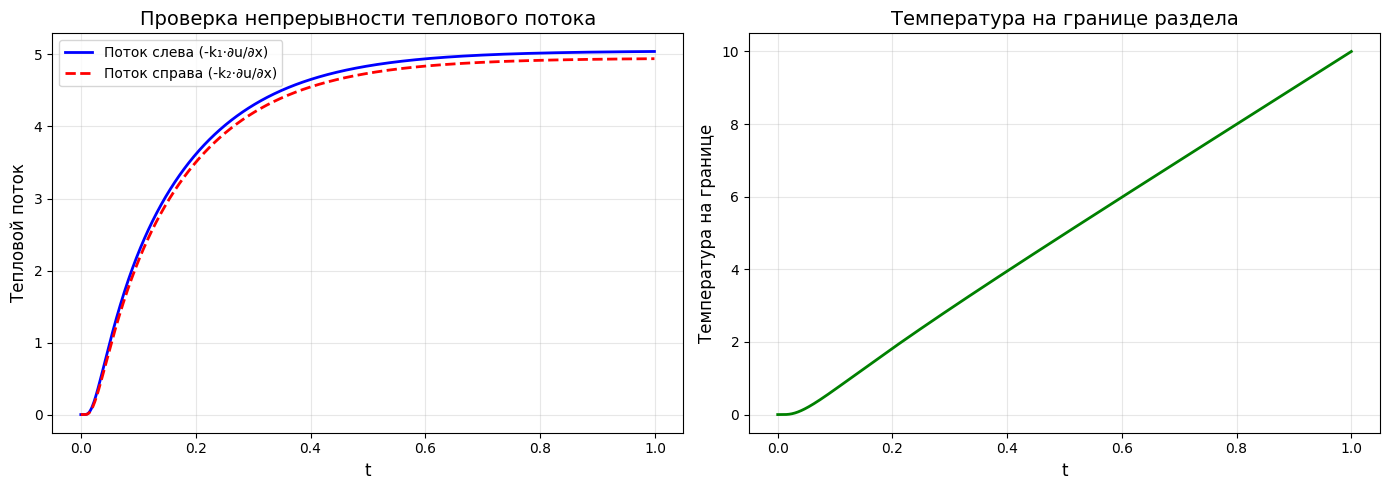

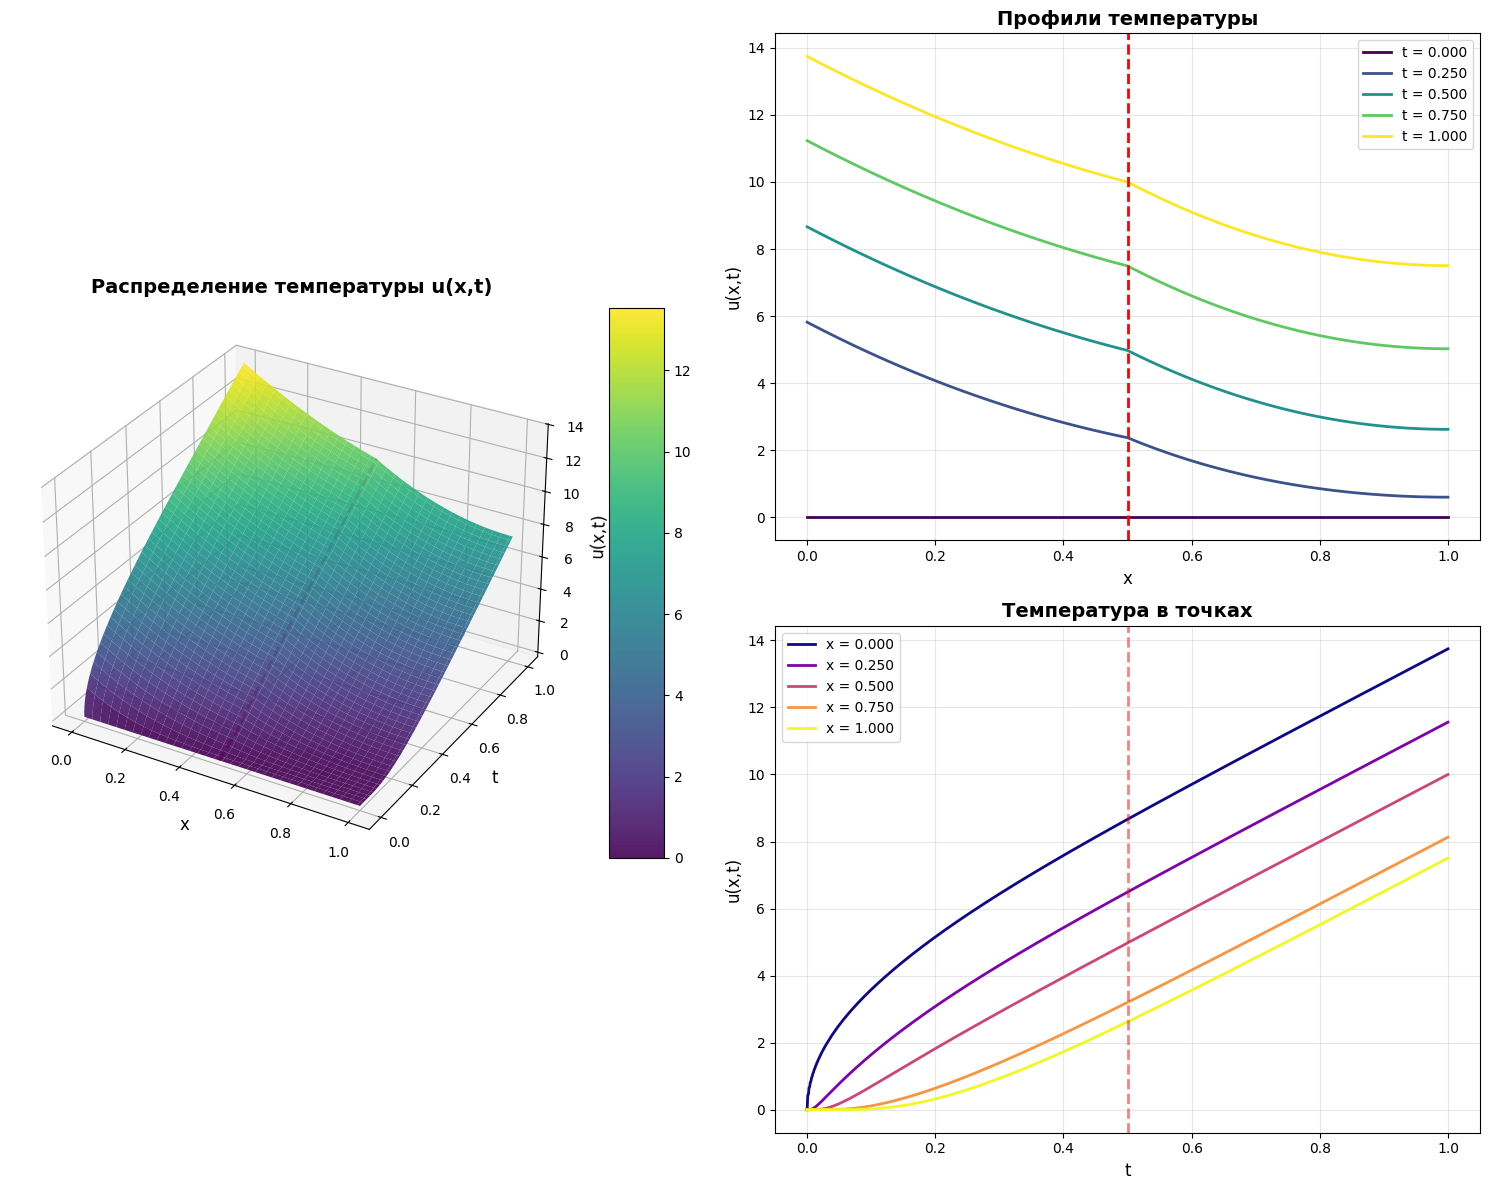

    Nx |       Nt |          h |           L2 |           L∞ |     p_L2 |     p_L∞
    40 |      400 |   0.025000 | 7.778556e-04 | 7.918499e-04 |        — |        —
    80 |      800 |   0.012500 | 1.921761e-04 | 1.956293e-04 |     2.02 |     2.02
   160 |     1600 |   0.006250 | 4.575624e-05 | 4.657819e-05 |     2.07 |     2.07
   320 |     3200 |   0.003125 | 9.151280e-06 | 9.315669e-06 |     2.32 |     2.32


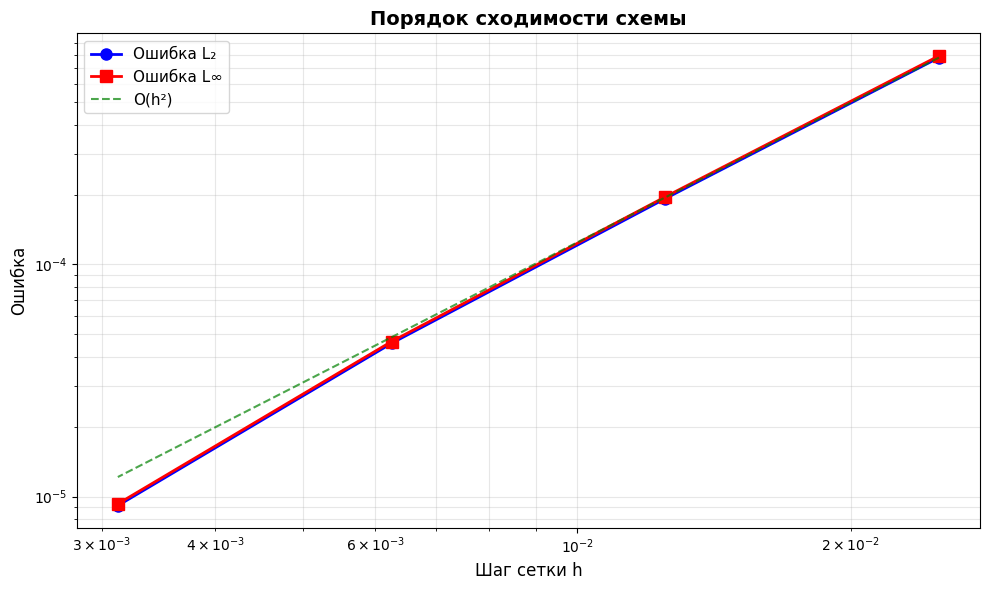

In [22]:
if __name__ == "__main__":
    x_min = 0.0
    x_max = 1.0
    t_max = 1.0
    a_interface = 0.5
    
    k1 = 1.0 
    k2 = 0.5
    q_flux = 10.0
    
    Nx = 100
    Nt = 1000
    
    # Решение задачи
    x, t, U = solve_heat_cn_composite(x_min, x_max, t_max, Nx, Nt, a_interface, k1, k2, q_flux, save_history=True)
    
    h = x[1] - x[0]
    tau = t[1] - t[0]
    
    print(f"\nШаг по пространству: h = {h:.3f}")
    print(f"Шаг по времени: τ = {tau:.3f}")
    print(f"Максимальная температура: u_max = {np.max(U):.6e}")
    print(f"Минимальная температура: u_min = {np.min(U):.6e}")

    check_interface_conditions(x, t, U, a_interface, k1, k2)
    plot_temperature_evolution(x, t, U, a_interface, k1, k2, q_flux)
    convergence_study_composite(x_min, x_max, t_max, a_interface, k1, k2, q_flux)